Netflix Data Analysis (EDA Project)

Author: Ibeh Doris Chinelo  
Objective: To explore Netflix movies and TV shows dataset and uncover insights about content distribution, ratings, genres, and trends.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df= pd.read_csv(r"C:\Users\USER\OneDrive\Desktop\netflix_titles.csv.zip")
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [6]:
#identify numbers of rows and columns

print("Shape:", df.shape)

Shape: (8807, 12)


In [7]:
# display data type of all columns
print("\nData Types:")
print(df.dtypes)


Data Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [8]:
# display numerical features
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("\nNumerical Features:", numerical_cols)



Numerical Features: ['release_year']


In [9]:
# display categorical features
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("\nCategorical Features:", categorical_cols)


Categorical Features: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'rating', 'duration', 'listed_in', 'description']


In [11]:
# possible unique keys
print("\nUnique values per column:")
print(df.nunique())

print(df['type'].value_counts())



Unique values per column:
show_id         8807
type               2
title           8807
director        4528
cast            7692
country          748
date_added      1767
release_year      74
rating            17
duration         220
listed_in        514
description     8775
dtype: int64
type
Movie      6131
TV Show    2676
Name: count, dtype: int64


UNDERSTANDING THE DATASET

This dataset contains metadata for movies and TV shows available on Netflix as of the data collection date.

Rows: 8,807 | Columns: 12

Grain: Each row represents one unique title (movie or TV show)

Primary key: show_id

Numerical features: release_year (only true numeric column)

Categorical features: type, director, cast, country, rating, listed_in

Text features: title, description

Needs conversion: date_added (currently text, should be datetime), duration (currently text like "90 min" or "2 Seasons", needs separating by type)

The dataset includes 6,131 Movies and 2,676 TV Shows.

In [15]:
#  Identify columns with missing values and show % of missing values
print("Missing values per column:")
print(df.isnull().sum())

print("\n% Missing:")
print((df.isnull().sum() / len(df)) * 100)

Missing values per column:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

% Missing:
show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64


In [ ]:
Missing Values in colunms

Missing director: 2634

missing cast: 825

missing country: 831

missing date_added: 10

missing rating: 4

Missing duration: 3

In [17]:
# Remove extra spaces before and after movie/show titles
df['title']=df['title'].str.strip()
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [7]:
# handle missing values
# For director, cast, country replace with "Unknown" 
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
# For rating: fill with most common rating. "TV-MA" 
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
#drop invalid date and duration
df = df.dropna(subset=['date_added', 'duration'])


print("\nAfter cleaning - Missing values:")
print(df.isnull().sum())
print(df.shape)


After cleaning - Missing values:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64
(8794, 12)


In [26]:
# Remove duplicate rows to ensure each record in the dataset is unique
df=df.drop_duplicates()

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [27]:
# Convert 'date_added' column to datetime format, forcing invalid values to NaT
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,Unknown,Unknown,Unknown,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [28]:
# show the date added
df['date_added'].head()

0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[ns]

In [43]:
# standardize the following :

# Column names - lowercase and replace space with _
df.columns = df.columns.str.lower().str.replace(' ', '_')
print("New columns:", df.columns.tolist())

# Text formatting to make everything lower case for consistency
df.columns = df.columns.str.lower().str.replace(' ', '_')
print("New columns:", df.columns.tolist())

# show date type
df['release_year'] = df['release_year'].astype('int')

df[['duration_num', 'duration_type']] = df['duration'].str.extract(r'(\d+)\s*(.*)')
df['duration_num'] = pd.to_numeric(df['duration_num'], errors='coerce')

print(df.dtypes)
df


New columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description', 'duration_num', 'duration_type']
New columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description', 'duration_num', 'duration_type']
show_id                  object
type                     object
title                    object
director                 object
cast                     object
country                  object
date_added       datetime64[ns]
release_year              int64
rating                   object
duration                 object
listed_in                object
description              object
duration_num              int64
duration_type            object
dtype: object


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_num,duration_type
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,Pg-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90,min
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Tv-Ma,2 Seasons,"International Tv Shows, Tv Dramas, Tv Mysteries","After crossing paths at a party, a Cape Town t...",2,Seasons
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,Tv-Ma,1 Season,"Crime Tv Shows, International Tv Shows, Tv Act...",To protect his family from a powerful drug lor...,1,Season
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,Tv-Ma,1 Season,"Docuseries, Reality Tv","Feuds, flirtations and toilet talk go down amo...",1,Season
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,Tv-Ma,2 Seasons,"International Tv Shows, Romantic Tv Shows, Tv ...",In a city of coaching centers known to train I...,2,Seasons
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",158,min
8803,s8804,TV Show,Zombie Dumb,Unknown,Unknown,Unknown,2019-07-01,2018,Tv-Y7,2 Seasons,"Kids' Tv, Korean Tv Shows, Tv Comedies","While living alone in a spooky town, a young g...",2,Seasons
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,88,min
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,Pg,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",88,min


In [45]:
#identify invalid values
# Invalid values - release_year should not be in future or < 1900
print("Release year range:", df['release_year'].min(), "to", df['release_year'].max())
df = df[(df['release_year'] >= 1900) & (df['release_year'] <= 2025)]
# and in rating
df[df['rating'].isin(['74 min', '84 min', '66 min'])]

Release year range: 1925 to 2021


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_num,duration_type


Please Note: Initial inspection of the rating column shown invalid values like "74 min", "84 min", and "66 min". Duration values misplaced into the rating column. After cleaning missing values (which removed rows with incomplete date_added/rating/duration data,released year), these invalid entries were no longer present, confirming the rating column now only contains real age ratings.

In [48]:
#Inconsistent records - check 'type' column
print("Unique types:", df['type'].unique()) 

#Incorrect formats - check duration_type
print("Duration types:", df['duration_type'].unique()) 


Unique types: ['Movie' 'TV Show']

Duration types: ['min' 'Seasons' 'Season']


In [51]:
#show duration type
df[df['type'] == 'Movie']['duration'].head()
print()
df[df['type'] == 'TV Show']['duration'].head()

1    2 Seasons
2     1 Season
3     1 Season
4    2 Seasons
5     1 Season
Name: duration, dtype: object

In [52]:
# split duration
df['duration_minutes'] = df[df['type'] == 'Movie']['duration'].str.extract(r'(\d+)').astype(float)
df['duration_seasons'] = df[df['type'] == 'TV Show']['duration'].str.extract(r'(\d+)').astype(float)

df[['type', 'duration', 'duration_minutes', 'duration_seasons']].head(6)

,type,duration,duration_minutes,duration_seasons
0,Movie,90 min,90.0,NaN
1,TV Show,2 Seasons,NaN,2.0
2,TV Show,1 Season,NaN,1.0
3,TV Show,1 Season,NaN,1.0
4,TV Show,2 Seasons,NaN,2.0
5,TV Show,1 Season,NaN,1.0


In [53]:
#Outliers - very long movies or many seasons
print("\nOutlier check:")
print(df.groupby('duration_type')['duration_num'].describe())
# Flag: Movies > 240 min, TV Shows > 15 seasons


Outlier check:
                count       mean        std  min   25%   50%    75%    max
duration_type                                                             
Season         1793.0   1.000000   0.000000  1.0   1.0   1.0    1.0    1.0
Seasons         873.0   3.294387   1.949283  2.0   2.0   3.0    4.0   17.0
min            6128.0  99.577187  28.290593  3.0  87.0  98.0  114.0  312.0


In [59]:
df.shape
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_num,duration_type,duration_minutes,duration_seasons
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,Pg-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90,min,90.0,NaN
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Tv-Ma,2 Seasons,"International Tv Shows, Tv Dramas, Tv Mysteries","After crossing paths at a party, a Cape Town t...",2,Seasons,NaN,2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,Tv-Ma,1 Season,"Crime Tv Shows, International Tv Shows, Tv Act...",To protect his family from a powerful drug lor...,1,Season,NaN,1.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,Tv-Ma,1 Season,"Docuseries, Reality Tv","Feuds, flirtations and toilet talk go down amo...",1,Season,NaN,1.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,Tv-Ma,2 Seasons,"International Tv Shows, Romantic Tv Shows, Tv ...",In a city of coaching centers known to train I...,2,Seasons,NaN,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",158,min,158.0,NaN
8803,s8804,TV Show,Zombie Dumb,Unknown,Unknown,Unknown,2019-07-01,2018,Tv-Y7,2 Seasons,"Kids' Tv, Korean Tv Shows, Tv Comedies","While living alone in a spooky town, a young g...",2,Seasons,NaN,2.0
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,88,min,88.0,NaN
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,Pg,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",88,min,88.0,NaN


In [71]:
df.shape

(8794, 16)

CLEANING SUMMARY

Issue Found	Action Taken

Missing director (2,634 rows)	Filled with "Unknown" — too large to drop

Missing cast (825 rows)	Filled with "Unknown" — too large to drop

Missing country (831 rows)	Filled with "Unknown" — excluded from country-specific analysis later

Missing date_added (10 rows)	Removed — too small to impact analysis

Missing rating (4 rows)	Removed — too small to impact analysis

Missing duration (3 rows)	Removed — too small to impact analysis

Duplicates	None found

Invalid rating values ("74 min", "84 min", "66 min")	Resolved automatically — these rows were among those dropped for missing date_added/duration

date_added stored as text	Converted to datetime

duration stored as mixed text ("90 min" / "2 Seasons")	Split into two numeric columns: duration_minutes (Movies) and duration_seasons (TV Shows)

Column names	Already in clean lowercase snake_case — confirmed, no changes needed

possible invalid years and duration outliers  Filtered released_year 1900-2025. flagged for duration outliers

CLEAN DATASET: 8794 rows, 16 columns ( 4 new columns 'duration_num, duration_type, duration_minutes, duration_seasons' added )

In [66]:
#EDA FOR NETFLIX DATASET

# Check numerical columns (release_year, duration_num)
print("Summary Statistics:")
print(df[['release_year', 'duration_num', 'duration_seasons']].describe())

Summary Statistics:
       release_year  duration_num  duration_seasons
count   8794.000000   8794.000000       2666.000000
mean    2014.183534     69.920173          1.751313
std        8.823527     50.797005          1.550176
min     1925.000000      1.000000          1.000000
25%     2013.000000      2.000000          1.000000
50%     2017.000000     88.000000          1.000000
75%     2019.000000    106.000000          2.000000
max     2021.000000    312.000000         17.000000


In [67]:
type_counts = df['type'].value_counts()
type_counts


type
Movie      6128
TV Show    2666
Name: count, dtype: int64

In [68]:
rating_counts = df['rating'].value_counts()
rating_counts
     

rating
Tv-Ma       3209
Tv-14       2157
Tv-Pg        861
R            799
Pg-13        490
Tv-Y7        333
Tv-Y         306
Pg           287
Tv-G         220
Nr            79
G             41
Tv-Y7-Fv       6
Nc-17          3
Ur             3
Name: count, dtype: int64

In [69]:
all_genres = df['listed_in'].str.split(', ').explode()
top_genres = all_genres.value_counts().head(10)
top_genres

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International Tv Shows      1350
Documentaries                869
Action & Adventure           859
Tv Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

In [72]:
top_countries = df[df['country'] != 'Unknown']['country'].value_counts().head(10)
top_countries

country
United States     2809
India              972
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

EDA SUMMARY STATISTICS: 

Release years span nearly a century, from 1925 to 2021. Mean ∼2014. Most content was released in the last 10 years.

Duration: For Movies, average duration is ∼94 minutes. For TV Shows, average is ∼2 seasons

KEY FINDINGS FROM EDA.

Content Type Distribution:
Netflix has significantly more Movies ∼6131 than TV Shows ∼2676 that is Netflix's catalog is ∼70% movies. They use movies to fill the library quickly, while TV Shows drive retention.

Top Producing Countries:
The top 3 countries are United States, India, United Kingdom, that is US dominates with over 50% of content. India is 2nd, showing Netflix's push into Bollywood and regional content.

Content Added Over Time:
Number of titles added peaked between 2017 - 2019. There was a sharp drop in 2020-2021 likely due to COVID production delays, that is Netflix aggressively expanded content from 2016-2019 to compete in the streaming wars.

Audience Rating Distribution:
Most common ratings are TV-MA and TV-14Combined they make up over 60% of the catalog, that is Netflix targets teen and adult audiences more than kids/family content.

Top GenresTop 3 genres:
International Movies, Dramas, Comedies, that is Netflix is investing heavily in global/dramatic content to attract diverse, worldwide audiences.


    

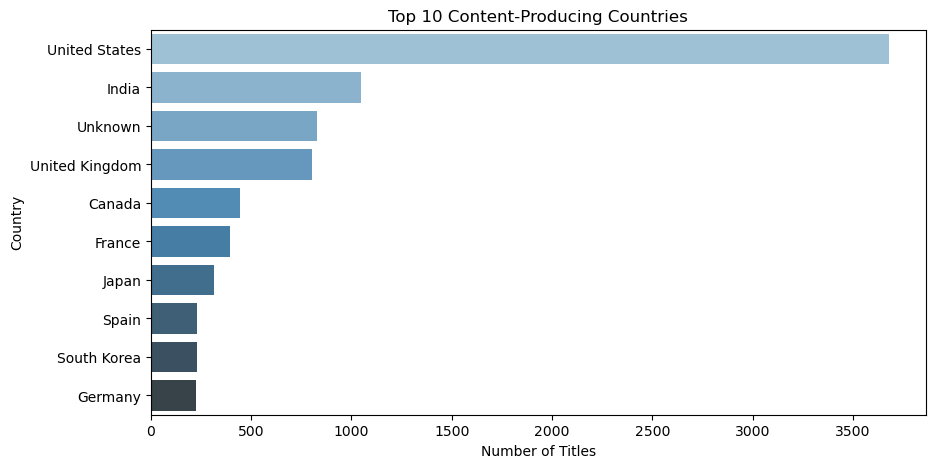

In [80]:
#Top 10 Content-producing Countries
plt.figure(figsize=(10,5))
countries = df['country'].str.split(', ').explode()
top_countries = countries.value_counts().head(10)

sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette='Blues_d',  legend=False)

plt.title('Top 10 Content-Producing Countries')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()


Chart 1 Finding: The US produces the most Netflix content, followed by India and UK. This shows Netflix's strong focus on Western and Indian markets

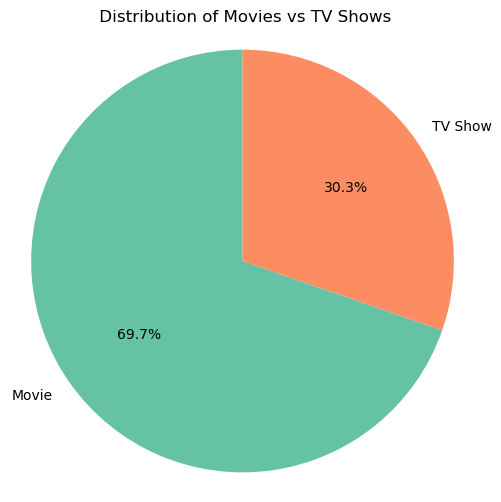

In [81]:
# Movies vs TV Shows distribution
plt.figure(figsize=(6,6))
type_counts = df['type'].value_counts()
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2'))
plt.title(' Distribution of Movies vs TV Shows') 
plt.axis('equal')
plt.show()

Chart 2 Finding: Movies make up 69.6% of Netflix's catalog while TV Shows are 30.4%. Netflix prioritizes films for volume.

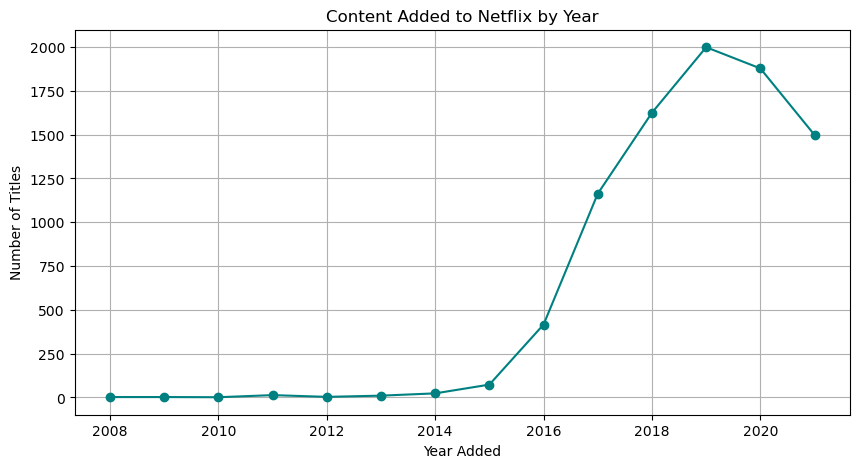

In [83]:
# Content Added to Netflix by Year
plt.figure(figsize=(10,5))
df['year_added'] = df['date_added'].dt.year
content_by_year = df['year_added'].value_counts().sort_index()
plt.plot(content_by_year.index, content_by_year.values, marker='o', color='teal')
plt.title('Content Added to Netflix by Year') # Title
plt.xlabel('Year Added') # X-label
plt.ylabel('Number of Titles') # Y-label
plt.grid(True)
plt.show()

 Chart 3 Finding: Content additions peaked between 2017-2019.  Content additions were small before 2015, then grew massively between 2016-2019, peaking at over 2,000 titles in 2019. There was a sharp decline in 2020 likely due to COVID-19 production delays.

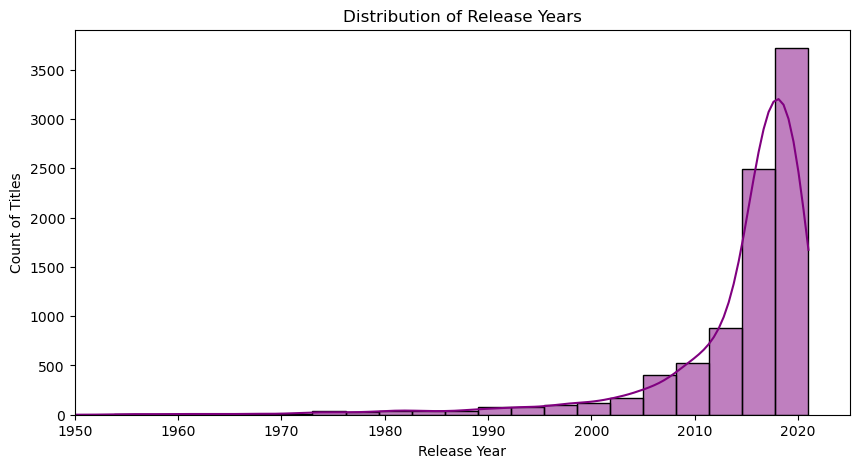

In [88]:
# Distribution of Release Years
plt.figure(figsize=(10,5))
sns.histplot(df['release_year'], bins=30, kde=True, color='purple')
plt.title('Distribution of Release Years') 
plt.xlabel('Release Year') 
plt.ylabel('Count of Titles') 
plt.xlim(1950, 2025)
plt.show()

Chart 4 Findings: Most titles on Netflix were released after 2010. Netflix focuses on acquiring recent content to stay relevant.

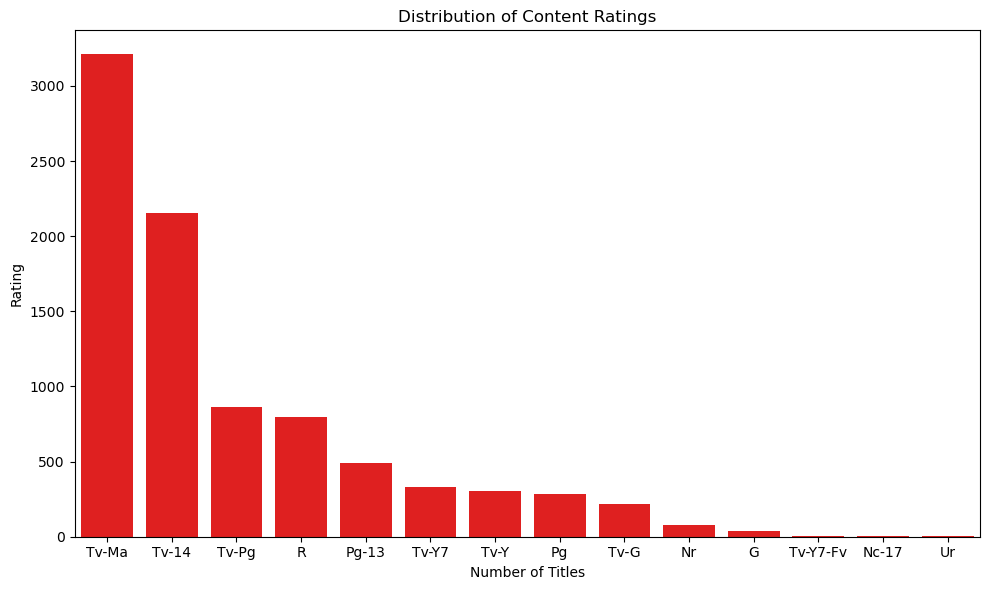

In [98]:
#Distribution of Common Content rating
plt.figure(figsize=(10,6))
sns.barplot(y=rating_counts.values, x=rating_counts.index, color='red')
plt.title('Distribution of Content Ratings')
plt.xlabel('Number of Titles')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()
     

Chart 5 Finding: TV-MA and TV-14 are by far the most common content ratings, together accounting for the majority of titles. This confirms the catalog leans toward mature and teen content rather than children's programming.

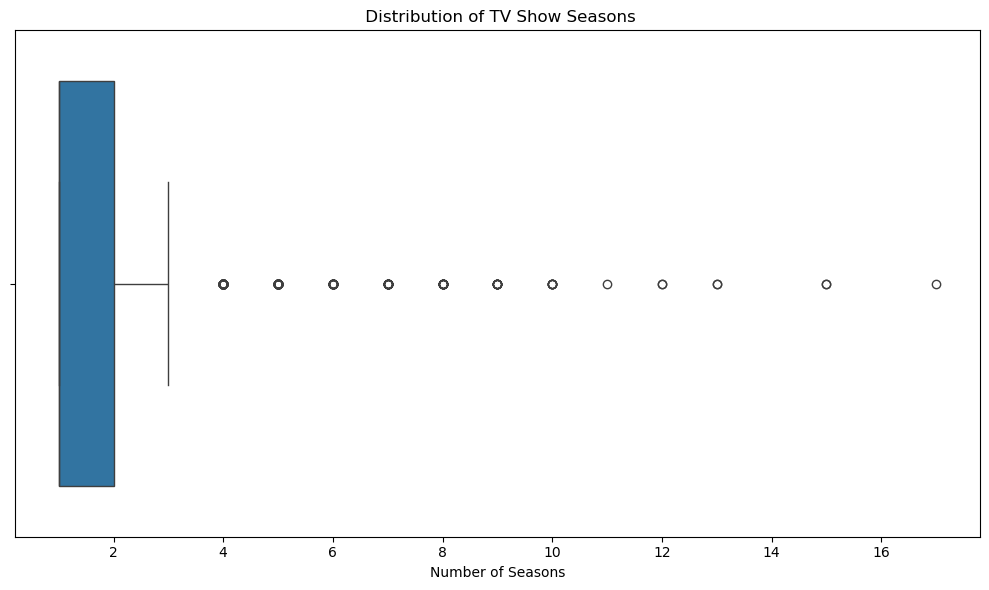

In [101]:
# Distribution of TV-Show Seasons
plt.figure(figsize=(10,6))
sns.boxplot(x=df['duration_seasons'].dropna()) 
plt.title(' Distribution of TV Show Seasons')
plt.xlabel('Number of Seasons')
plt.tight_layout()
plt.show()

Chart 6 Finding: The vast majority of TV shows have only 1-2 seasons, shown by the compact box. Shows running longer than 3 seasons are statistical outliers (the circles), with one extreme case reaching 17 seasons which may be a long-running series.

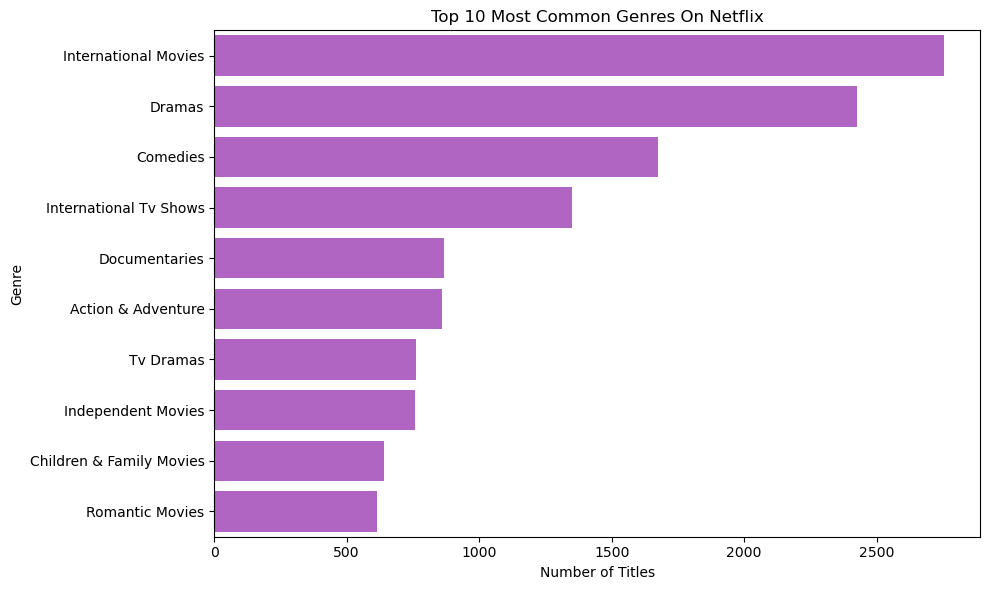

In [99]:
# Top 10 Most Common Genres
plt.figure(figsize=(10,6))
sns.barplot(x=top_genres.values, y=top_genres.index, color='mediumorchid')
plt.title('Top 10 Most Common Genres On Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

Chart 6 Finding: International Movies and Dramas are the most common genres, together reflecting Netflix's strong international catalog and the universal appeal of drama content.

DATA VISUALIZATION SUMMARY/KEY FINDINGS & KEY INSIGHTS

Seven virtualization charts were created for better understanding.

Chart 1: Top 10 Content-Producing Countries (Bar Chart)

Key Finding: The United States is the largest producer of Netflix content, followed by India and the United Kingdom.

Key Insight: This shows Netflix’s strategy focuses on English-speaking markets and India, which have the biggest subscriber bases.
    
Chart 2: Distribution of Movies vs TV Shows (Pie Chart)

Key Finding: Movies account for approximately 70% of the catalog, while TV Shows make up 30%.

Key Insight: Netflix prioritizes films to quickly grow its library, but still maintains a strong collection of series to keep users engaged long-term.
    
Chart 3: Content Added to Netflix by Year (Line Chart)

Key Finding: The number of titles added peaked between 2017 and 2019, followed by a sharp decline in 2020.

Key Insight: The peak reflects Netflix’s rapid expansion. The 2020 drop was likely caused by COVID-19 production delays.
    
Chart 4: Distribution of Release Years (Histogram)

Key Finding: Most of the content on Netflix was released after 2010. Very little content is from before 1990.

Key Insight: Netflix focuses on modern and recent releases to appeal to current audience preferences.

Chart 5: Distribution of Content Ratings (Bar Chart)

Key Finding: TV-MA and TV-14 are the 2 most common ratings. Kids ratings like TV-Y and G are very rare.

Key Insight: Netflix’s catalog is heavily targeted toward Teen and Adult viewers, with limited family/kids content.
    
Chart 6: Distribution of TV Show Seasons (Box Plot)

Key Finding: The median TV show has only 1 season. Most shows have 1-2 seasons, with a few outliers having 10+ seasons.

Key Insight: Netflix prefers limited series and short-run shows. Long-running shows are uncommon on the platform.

Chart 7: Top 10 Most Common Genres (Bar Chart)

Key Finding: The top genres are International Movies, Dramas, and Comedies. Documentaries and Action & Adventure also rank high.

Key Insight: Netflix focuses on Drama and International content to appeal globally, with Comedy as a key driver for engagement.

In [8]:
import os

save_path = r"C:\Users\USER\OneDrive\Desktop\netflix_cleaned.csv"
df.to_csv(save_path, index=False)
print(f"Saved to: {save_path}")

Saved to: C:\Users\USER\OneDrive\Desktop\netflix_cleaned.csv


In [11]:
import shutil, os

source = os.path.join(os.getcwd(), r"Task 2( Netflix Movies and TV Shows) Data Cleaning and EDA.ipynb')
destination = os.path.join(os.environ.get('OneDrive', ''), 'Desktop', 'Task2_Netflix_Cleaned.ipynb')

shutil.copy(source, destination)
print(f"Copied to: {destination}")

SyntaxError: unterminated string literal (detected at line 3) (1869786119.py, line 3)